# Beer-Lambert Depth Estimation (Relative Seafloor Height)

Estimates local seafloor height variations from pseudo-reflectance using Beer-Lambert attenuation law.

**Physics**: Underwater light follows exponential attenuation → bright pixels = shallow/elevated (bombs), dark pixels = deep (pits)

**Workflow**:
1. Load transect and apply illumination correction
2. Compute Beer-Lambert depth: `cube.compute_beer_lambert_depth()`
3. Visualize heatmap: `cube.plot_georef(depth_overlay=True)`

In [1]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

In [2]:
# Quick verification: Check that depth methods are loaded
print("✓ Loaded georef from:", georef.__file__)
print(
    "✓ compute_beer_lambert_depth available:",
    hasattr(georef.CombinedTransectCube, "compute_beer_lambert_depth"),
)

import inspect

print(
    "✓ plot_georef has depth_overlay parameter:",
    "depth_overlay"
    in inspect.signature(georef.CombinedTransectCube.plot_georef).parameters,
)

✓ Loaded georef from: e:\mjosa_complete\gref4hsi\mjosa_code\utils\uhi\georef.py
✓ compute_beer_lambert_depth available: True
✓ plot_georef has depth_overlay parameter: True


## Step 1: Load Transect 057

In [3]:
# Load transect 057
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select file 5
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)


## Step 2: Apply Illumination Correction

**Important**: Beer-Lambert depth estimation requires illumination-corrected data

In [4]:
# Apply illumination correction with 500px window (default)
cube.apply_illumination_correction_v2(window_size=500)

🔄 Using V2 algorithm (pandas rolling median, memory-efficient)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

## Step 3: Compute Beer-Lambert Depth

Calculate relative seafloor height from attenuation

🌊 Computing Beer-Lambert relative depth estimation...
Track range: 576 to 1566 (990 tracks)
Spatial pixels: 968
Spectral bands: 210
\nAttenuation coefficients c(λ):
   Interpolated from 8 reference points
   Range: 0.320 to 0.580 m⁻¹
   Mean (500-650 nm): 0.354 ± 0.027 m⁻¹


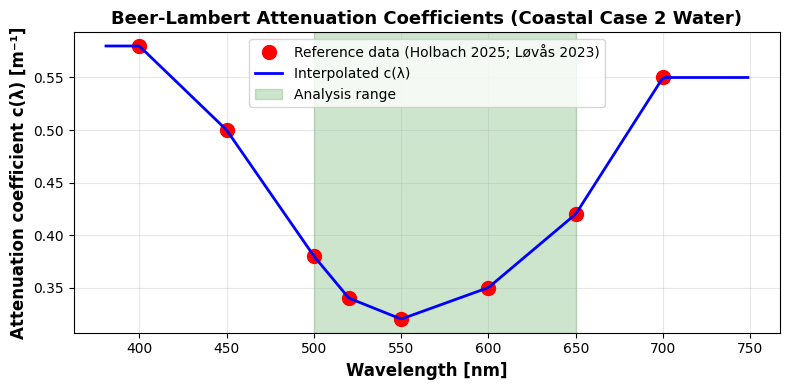

✅ Attenuation curve plotted
⚠️  WARNING: Found 12550015 non-positive pixels (6.236%)
   Setting to small positive value (1e-10) to avoid ln() errors
\n🔄 Computing local reference intensity (rolling mean, window=500 px)...
✅ Local reference computed
\n🧮 Computing per-wavelength relative depth Δz(λ)...
✅ Per-wavelength depth computed
   Shape: (990, 968, 210)
   Range: -27.953 to 4.628 m
\n📊 Averaging depth across wavelength range 500-650 nm...
   Using 85 bands
✅ Mean depth computed
   Shape: (990, 968)
   Mean: -0.000 m
   Std:  0.057 m
   Min:  -0.743 m (deepest/darkest)
   Max:  0.436 m (shallowest/brightest)
\n✅ Beer-Lambert depth estimation complete!
   Results stored in:
   - cube.depth_map (2D array, mean depth)
   - cube.depth_spectral (3D array, per-wavelength depth)
   - cube.depth_wavelengths (wavelengths used)
   - cube.depth_attenuation (c(λ) coefficients)
\n💡 Visualize with: cube.plot_georef(depth_overlay=True)


In [5]:
# Compute Beer-Lambert depth estimation
cube.compute_beer_lambert_depth(
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    window_size=500,  # Rolling mean window (same as illumination correction)
    wavelength_range=(500, 650),  # Optical window with stable attenuation
    quiet=False,
)

## Step 4: Visualize Depth Heatmap

Display depth variations using `plot_georef` with depth overlay

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
🎨 UHI plot_georef depth colorbar range: depth_vmin=-0.1423, depth_vmax=0.1069
💡 Interactive mode: Click on the plot to display coordinates


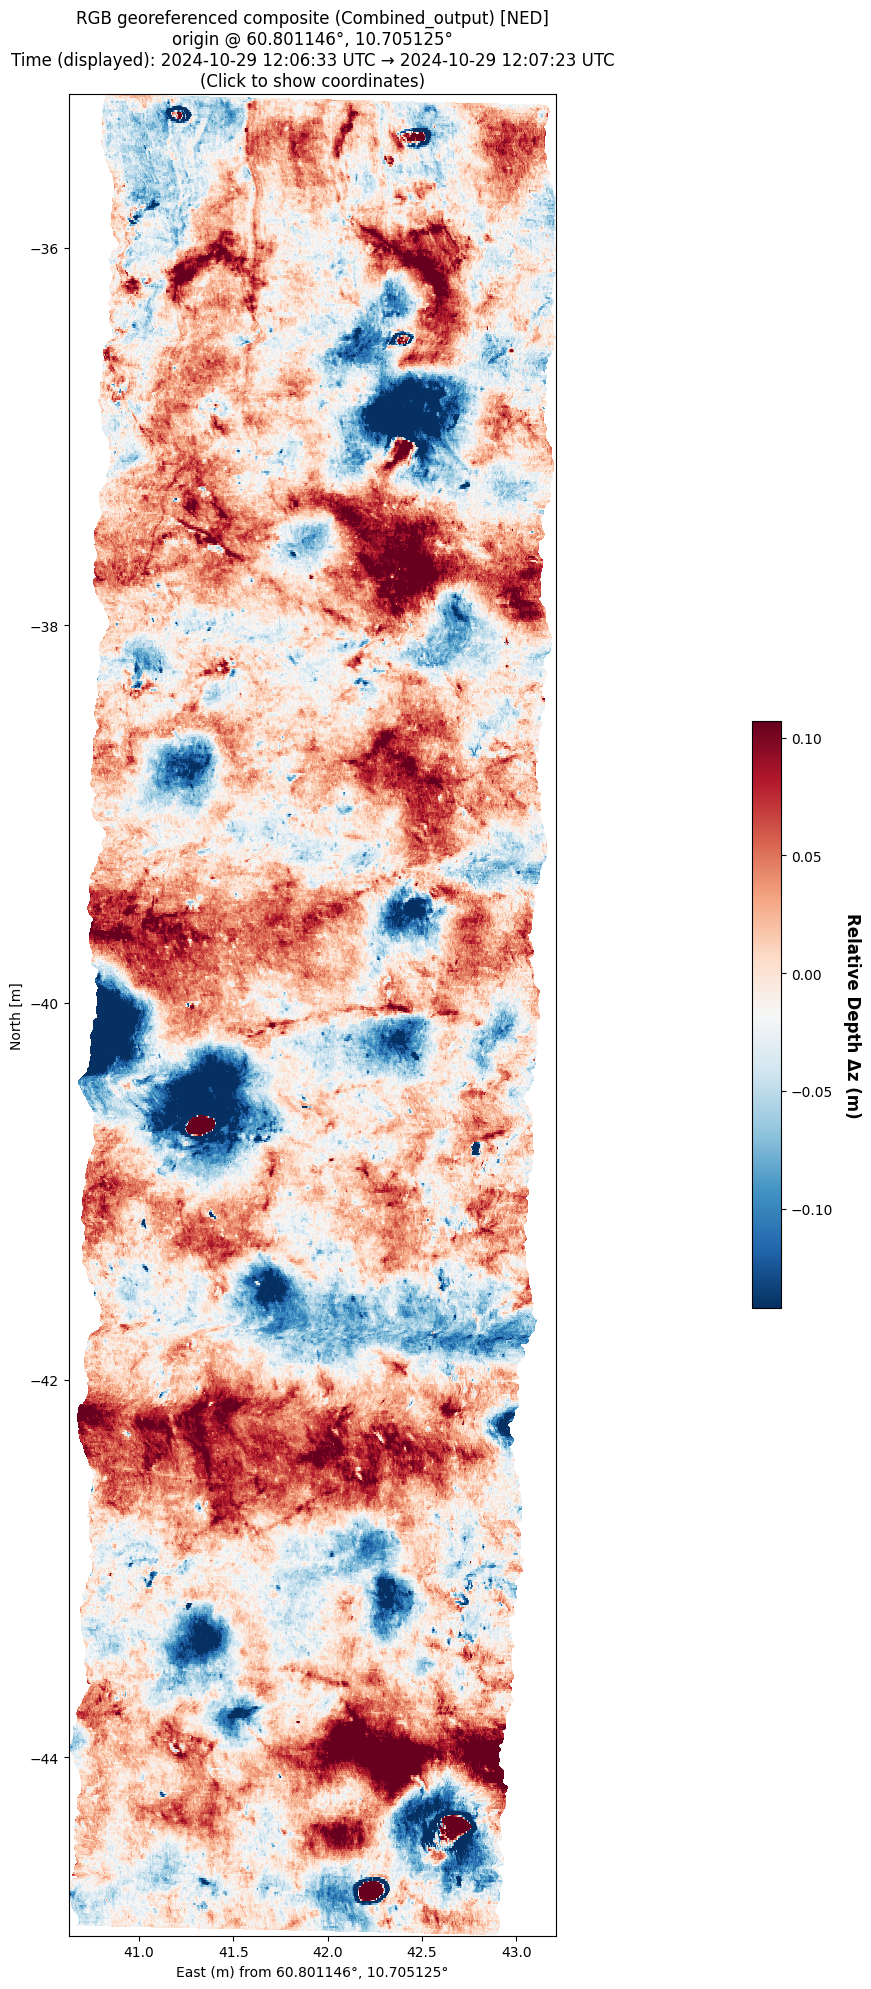

In [6]:
# Plot depth heatmap with all cartographic features
cube.plot_georef(
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    apply_alignment_shift=True,
    # DEPTH OVERLAY MODE
    depth_overlay=True,  # Use depth instead of RGB
    depth_cmap="RdBu_r",  # Blue=elevated/shallow, Red=deep/pits (SWAPPED COLORS)
    depth_vmin=None,  # Auto (2nd percentile)
    depth_vmax=None,  # Auto (98th percentile)
    depth_cbar_fraction=0.006,  # Colorbar width (increase for wider bar)
    depth_cbar_pad=0.04,  # Colorbar padding (increase to move away from plot)
    depth_cbar_shrink=0.5,  # Colorbar height (0.0-1.0, decrease for shorter bar)
    # Cartographic features (inherited from plot_georef)
    figsize=(50, 20),
    vmin=-0.145,
    vmax=0.11,
    # add_scale_bar=True,
    # scale_bar_length_m=1.0,
    # scale_bar_position="lower left",
    # scale_bar_color="black",
    # scale_bar_fontsize=20,
    # scale_bar_linewidth=4,
    # add_north_arrow=True,
    # north_arrow_position="upper right",
    # north_arrow_size=0.1,
    # north_arrow_color="black",
    # north_arrow_linewidth=4,
    # north_arrow_head_size=40,
)

## Optional: Custom Depth Range

Manually set depth colormap range for better contrast

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
🎨 UHI plot_georef depth colorbar range: depth_vmin=-0.2000, depth_vmax=0.2000
💡 Interactive mode: Click on the plot to display coordinates


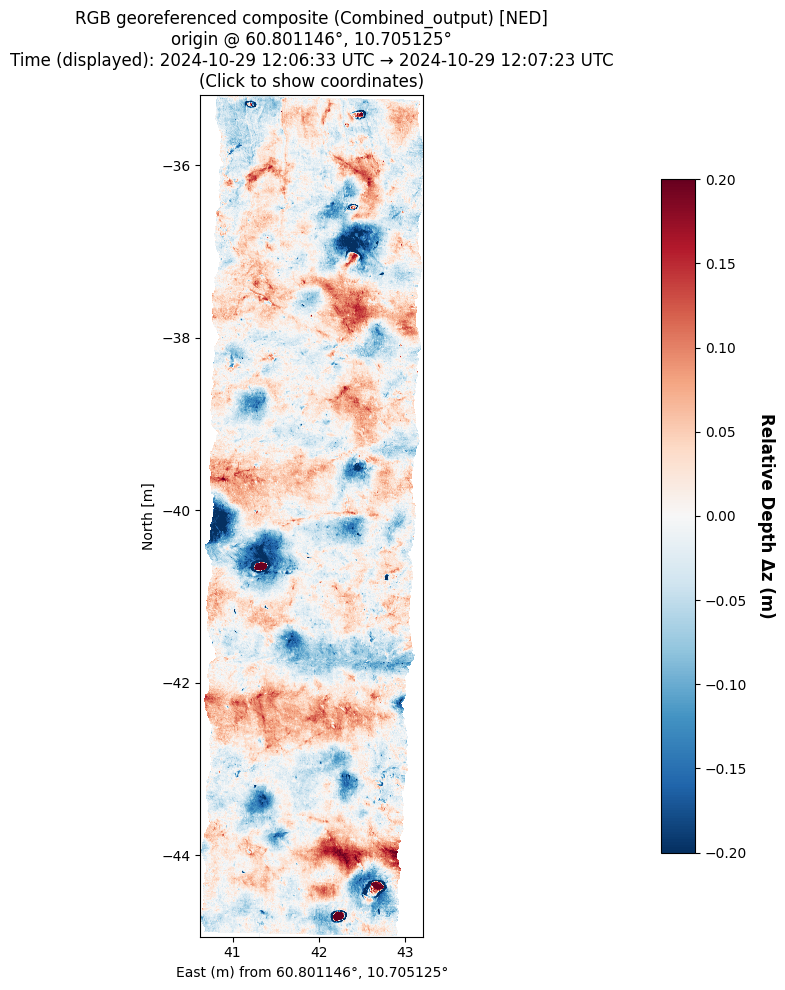

In [7]:
# Plot with custom depth range (e.g., ±0.2 m around mean)
cube.plot_georef(
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    apply_alignment_shift=True,
    depth_overlay=True,
    depth_cmap="RdBu_r",  # Blue=elevated, Red=deep
    depth_vmin=-0.2,  # Manual min (meters)
    depth_vmax=0.2,  # Manual max (meters)
    depth_cbar_fraction=0.08,  # Example: Wider colorbar
    depth_cbar_pad=0.06,  # Example: More spacing from plot
    depth_cbar_shrink=0.8,  # Example: Shorter colorbar (80% of axis height)
    figsize=(40, 10),
)

## Summary

✅ **Beer-Lambert depth estimation complete!**

**Key Results:**
- `cube.depth_map`: 2D array of mean relative depth (meters)
- `cube.depth_spectral`: 3D array of per-wavelength depth
- `cube.depth_wavelengths`: Wavelengths used (500-650 nm)
- `cube.depth_attenuation`: c(λ) coefficients

**Interpretation:**
- **Red/warm colors**: Shallow / elevated areas (bombs, mounds)
- **Blue/cool colors**: Deep / depressed areas (pits)
- **Typical range**: 0-0.5 meters
- **Similar to**: MBES residuals (local height variations)